# Task1 : Movie Genre Classification
    We are tasked to design an Movie Genre classifier based on previous movie data in this colab notebook we are going to
    create a machine learning model that can predict the genre of a movie based on its plot summary or other textual
    information. we are going to use techniques like TF-IDF or word embeddings with classifiers such as Naive Bayes,
    Logistic Regression, or Support Vector Machines.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Methodology:

###  1. Data Collection
###  2. Data Cleaning and Preprocessing
###  3. Data Visualization
###  4. Feature Engineering
###  5. Model Selection
###  6. Model Training and Evaluation

# Import necessary libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from wordcloud import WordCloud


In [ ]:
import nltk
import os

# Set the custom download path for NLTK data
custom_download_path = '/kaggle/working/nltk_data'

# Make sure the directory exists; if not, create it
os.makedirs(custom_download_path, exist_ok=True)

# Append the custom download path to NLTK data path
nltk.data.path.append(custom_download_path)

# Download NLTK resources to the custom path
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')




[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

# 1. Data Collection
    For the purpose of designing a Movie Genre classifier, we collected the dataset from Kaggle. The dataset consists of
    
    movie-related information sourced from the Internet Movie Database (IMDb). IMDb is a widely recognized online database
    
    that provides comprehensive details about movies, TV shows, cast and crew, ratings, reviews, and more.

    The dataset contains a diverse range of textual information, including plot summaries and other relevant details about
    
    
    various movies. This textual data will serve as the basis for training our machine learning model to predict the genre of a movie.

In [ ]:
# Read the txt files using pandas

train_data = pd.read_csv("/content/drive/MyDrive/Movie Genre Classification/train_data.txt", delimiter=':::' ,header = None ,engine='python')
test_data  = pd.read_csv("/content/drive/MyDrive/Movie Genre Classification/test_data.txt", delimiter=':::' ,header = None ,engine='python')

test_data_solution  = pd.read_csv("/content/drive/MyDrive/Movie Genre Classification/test_data_solution.txt", delimiter=':::' ,header = None ,engine='python')

In [ ]:
## View train data
print("shape",train_data.shape)
train_data.head()


shape (54214, 4)


,0,1,2,3
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


In [ ]:
## View the test solution data
print("shape",test_data_solution.shape)
test_data_solution.head()

shape (54200, 4)


,0,1,2,3
0,1,Edgar's Lunch (1998),thriller,"L.R. Brane loves his life - his car, his apar..."
1,2,La guerra de papá (1977),comedy,"Spain, March 1964: Quico is a very naughty ch..."
2,3,Off the Beaten Track (2010),documentary,One year in the life of Albin and his family ...
3,4,Meu Amigo Hindu (2015),drama,"His father has died, he hasn't spoken with hi..."
4,5,Er nu zhai (1955),drama,Before he was known internationally as a mart...


In [ ]:
## We will concat the test and train file

df = pd.concat((train_data ,test_data_solution))
df.columns = ["id" ,"Title","Genre","Description"]
df.head()

,id,Title,Genre,Description
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


In [ ]:
## Check the size
df.shape

(108414, 4)

# 2. Data Cleaning and Preprocessing
    We will clean and preprocess the data
    - Removing duplicates
    - Removing Nan rows and column
    - Preprocessing the Data
    

In [ ]:
## Check for Duplicates and Remove them
df.duplicated().sum() ## Will give us a number of duplicates

df.drop_duplicates(inplace = True)  ## Will drops any duplicates

In [ ]:
## Check for nan values

df.isna().sum()  # Will check for any duplicates

df.dropna( inplace = True ) ## Will drop any nan containing row if exists

In [ ]:
## Check the size
df.shape

(108414, 4)

In [ ]:
## function to preprocess the data
stopword = set(stopwords.words('english'))

def preprocessing(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation using regular expressions
    text = re.sub(r'[^\w\s]', '', text)

    # Remove specific characters #, @, and $
    text = re.sub(r'[#@\$]', '', text)

    # tokenize and convert to list
    tokens = word_tokenize(text)

    ## Lemmatize it
    lemmatizer  = WordNetLemmatizer()

    ## lemmatize each token
   # text = [lemmatizer.lemmatize(token) for token in tokens]
    text = text.split()

    text = [word for word in text if word not in stopword]


    return " ".join(text)



In [ ]:
## Create list of words in discription column
import nltk
nltk.download('punkt_tab')
df["Despcription_clean"] =  df["Description"].apply(preprocessing)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
df.head()

,id,Title,Genre,Description,Despcription_clean
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...,listening conversation doctor parents 10yearol...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...,brother sister past incestuous relationship cu...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...,bus empties students field trip museum natural...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...,help unemployed father make ends meet edith tw...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...,films title refers unrecovered bodies ground z...


# 3. Data Visualization
    Will try to analyse the data using Histogram and Bar Chart.
    And will show word cloud for each genre.
    

In [ ]:
## Shows us the label counts
df["Genre"].value_counts()

,count
Genre,
drama,27225
documentary,26192
comedy,14893
short,10145
horror,4408
thriller,3181
action,2629
western,2064
reality-tv,1767


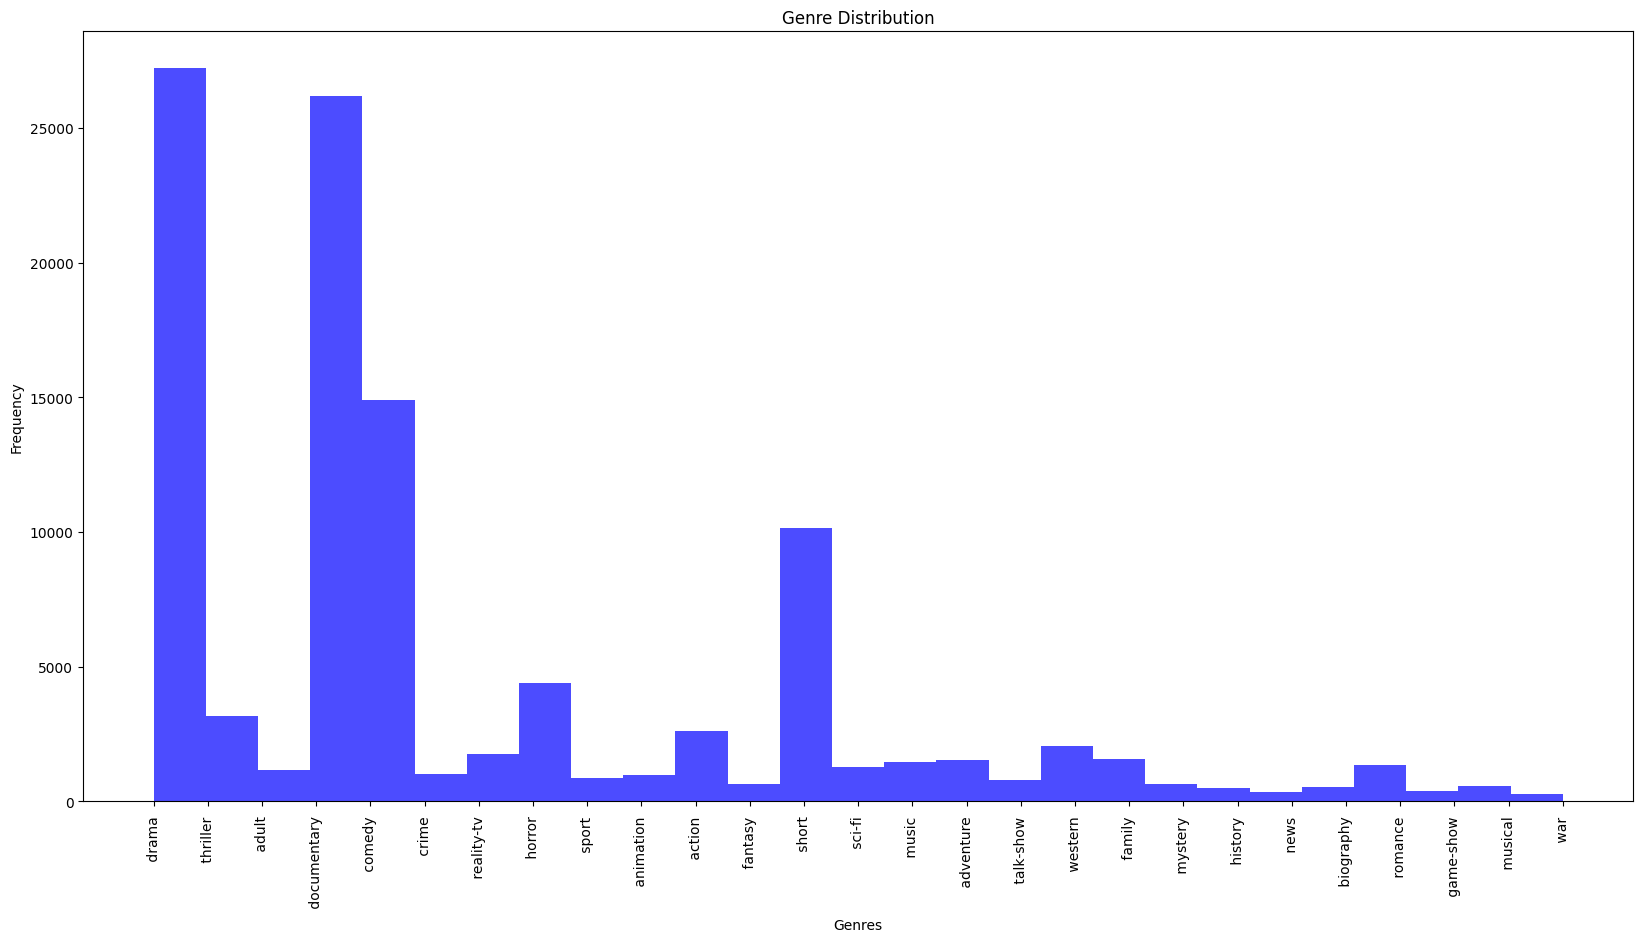

In [ ]:
# Create a histogram of genre distribution
plt.figure(figsize=(20, 10))
plt.hist(df["Genre"],bins =27 , color='blue', alpha=0.7)
plt.title("Genre Distribution")
plt.xlabel("Genres")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.show()

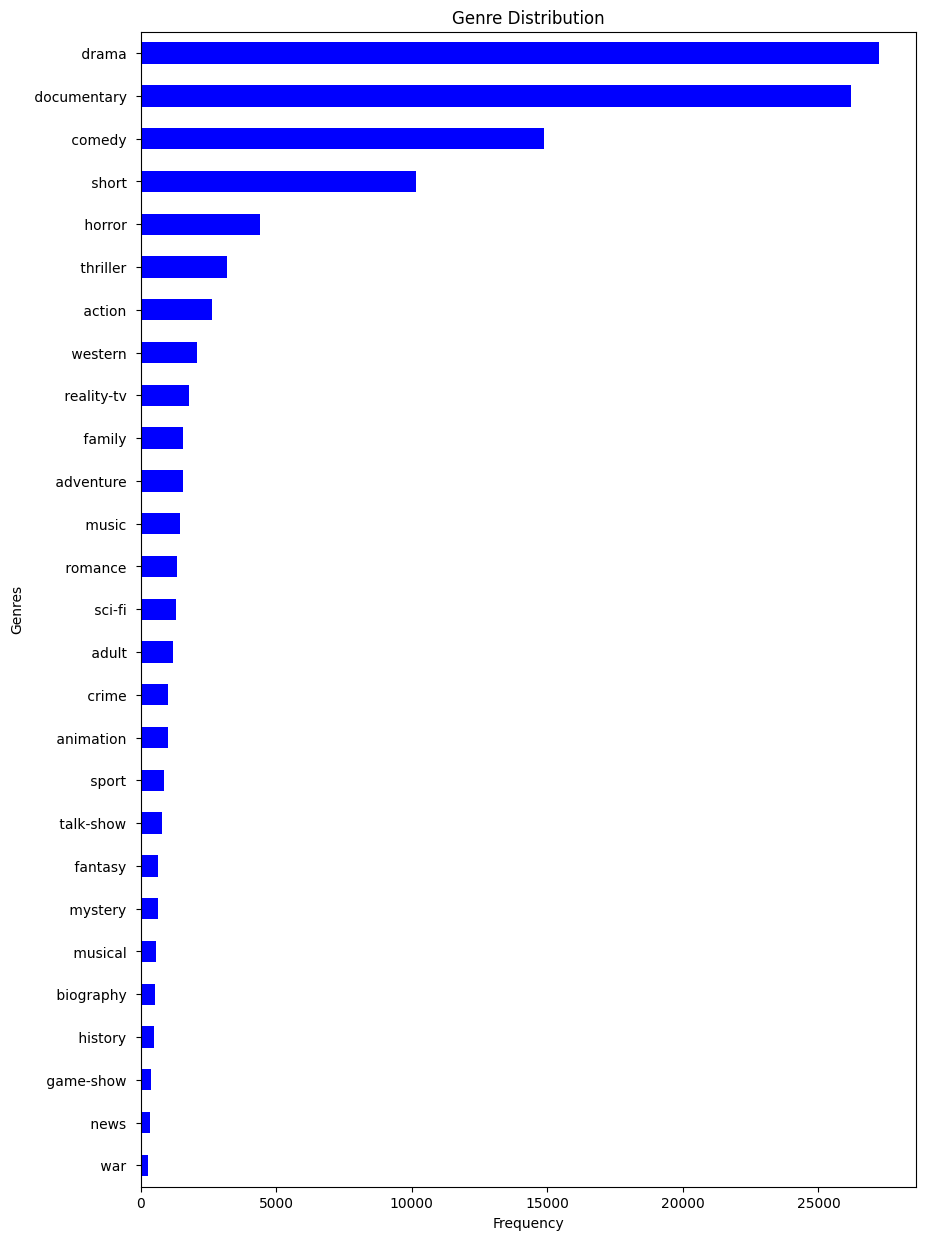

In [ ]:
## View genre distribution on Horizontal graph

genre_counts = df["Genre"].value_counts()
sorted_genres = genre_counts.sort_values(ascending=True)
# Create a horizontal histogram of genre distribution
plt.figure(figsize=(10, 15))
sorted_genres.plot(kind='barh',color = "blue", alpha=1 )
plt.title("Genre Distribution")
plt.xlabel("Frequency")
plt.ylabel("Genres")
plt.show()

In [ ]:
## Below code will generate wordcloud of each genre

# Create a list of unique genres from the dataset
genres = df['Genre'].unique()

# Set the figure size outside the loop
plt.figure(figsize=(20, 60))

# Iterate over each genre
for i, genre in enumerate(genres, 1):
    plt.subplot(14, 2, i)  # Assuming you have 14 rows and 2 columns for 28 genres
    text_subset = " ".join(list(df[df["Genre"] == genre]['Description']))
    wordcloud = WordCloud(max_words=300, width=300, height=100, background_color='white').generate(text_subset)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for {genre} Genre',fontsize=30)
    plt.axis('off')


plt.tight_layout()
plt.show()


# 4. Feature Engineering
      In this step we will remove unnecessary column which are not necessary for our model

In [ ]:
## remove id column from head
data = df.drop(["Title","id"] , axis = 1) # will drop column
data.head()


,Genre,Description,Despcription_clean
0,drama,Listening in to a conversation between his do...,listening conversation doctor parents 10yearol...
1,thriller,A brother and sister with a past incestuous r...,brother sister past incestuous relationship cu...
2,adult,As the bus empties the students for their fie...,bus empties students field trip museum natural...
3,drama,To help their unemployed father make ends mee...,help unemployed father make ends meet edith tw...
4,drama,The film's title refers not only to the un-re...,films title refers unrecovered bodies ground z...


# 5. Model Selection & Training
  - In this section we will try to apply CountVectorizer and TF-IDF technique and try to predict accuracy on model.

### Importing necessary libraries for model selection and training

In [ ]:
## import necessary library for
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay


### Converting Genre into Numerical form

In [ ]:
#Convert sentiment labels to numerical values for modeling
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
data['Genre_encoded'] = label_encoder.fit_transform(data['Genre'])
data['Genre_encoded']

class_names= list(label_encoder.classes_)
class_names

[' action ',
 ' adult ',
 ' adventure ',
 ' animation ',
 ' biography ',
 ' comedy ',
 ' crime ',
 ' documentary ',
 ' drama ',
 ' family ',
 ' fantasy ',
 ' game-show ',
 ' history ',
 ' horror ',
 ' music ',
 ' musical ',
 ' mystery ',
 ' news ',
 ' reality-tv ',
 ' romance ',
 ' sci-fi ',
 ' short ',
 ' sport ',
 ' talk-show ',
 ' thriller ',
 ' war ',
 ' western ']

In [ ]:
data.head()

,Genre,Description,Despcription_clean,Genre_encoded
0,drama,Listening in to a conversation between his do...,listening conversation doctor parents 10yearol...,8
1,thriller,A brother and sister with a past incestuous r...,brother sister past incestuous relationship cu...,24
2,adult,As the bus empties the students for their fie...,bus empties students field trip museum natural...,1
3,drama,To help their unemployed father make ends mee...,help unemployed father make ends meet edith tw...,8
4,drama,The film's title refers not only to the un-re...,films title refers unrecovered bodies ground z...,8


### Split the data to test and train

In [ ]:
## Split the data
x = data["Despcription_clean"]
y = data["Genre"]

x_train ,x_test ,y_train ,y_test = train_test_split(x ,y ,test_size = 0.5)

## Model training using CountVectorizer technique

In [ ]:
vectorize = CountVectorizer()
x_train1 = vectorize.fit_transform(x_train)
x_test1 =  vectorize.transform(x_test)

### MultinomialNB

Model Score on Training data 0.6403232054900658
Model Score on Training data 0.522552437877027
               precision    recall  f1-score   support

      action        0.04      0.69      0.08        80
       adult        0.01      0.78      0.02         9
   adventure        0.06      0.42      0.10       102
   animation        0.00      0.00      0.00         0
   biography        0.00      0.00      0.00         2
      comedy        0.45      0.53      0.49      6372
       crime        0.00      0.00      0.00         1
 documentary        0.90      0.56      0.69     20674
       drama        0.83      0.46      0.59     24510
      family        0.01      0.17      0.01        24
     fantasy        0.00      0.00      0.00        11
   game-show        0.14      0.97      0.25        29
     history        0.00      0.00      0.00         0
      horror        0.27      0.76      0.40       784
       music        0.06      0.79      0.11        52
     musical        0.01

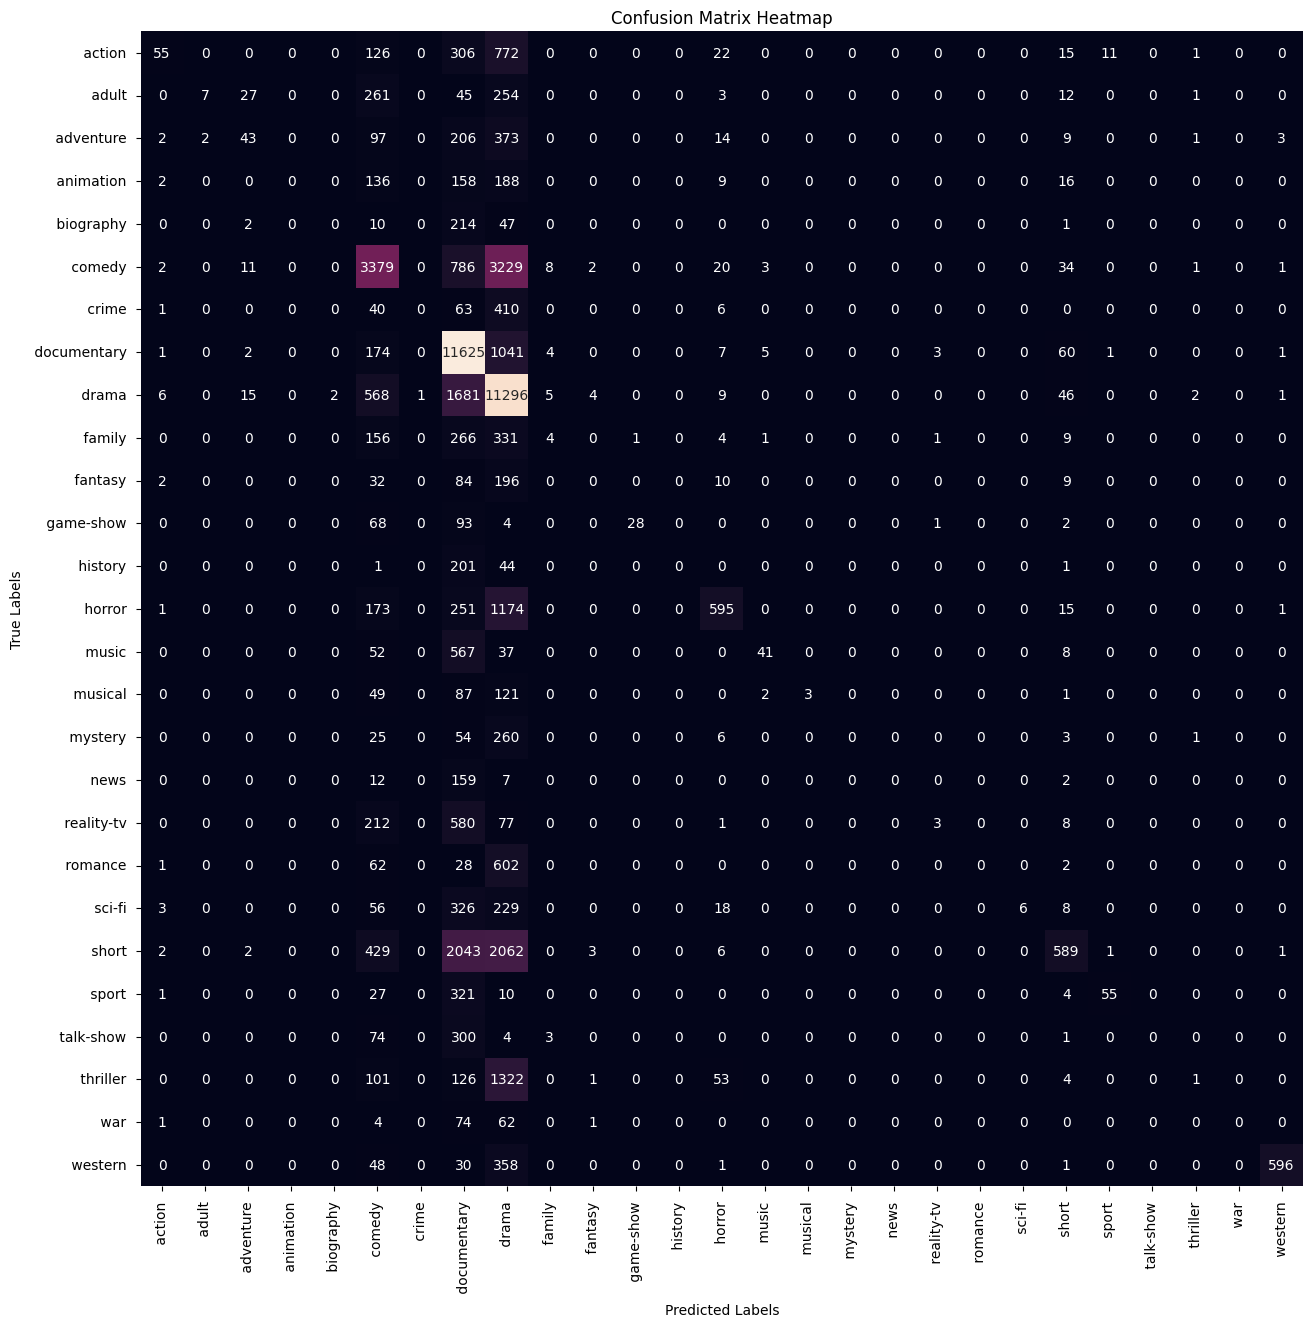

In [ ]:
mnb = MultinomialNB()
mnb.fit(x_train1 ,y_train)
print("Model Score on Training data",mnb.score(x_train1 ,y_train))
print("Model Score on Training data",mnb.score(x_test1 ,y_test))
y_pred = mnb.predict(x_test1)

print(classification_report(y_pred ,y_test))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(15, 15))  # Adjust the figure size as needed
sns.heatmap(cm, annot=True, fmt='d', cbar=False,
            xticklabels=class_names, yticklabels=class_names)  # Replace 'class_names' with your class labels
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()


### LogisticRegression

In [ ]:
## select Logistic regression for this
model = LogisticRegression()
model.fit(x_train1 ,y_train)
print("Model Score on Training data",model.score(x_train1 ,y_train))
print("Model Score on Training data",model.score(x_test1 ,y_test))
y_pred = model.predict(x_test1)
print(classification_report(y_pred ,y_test))


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(15, 15))  # Adjust the figure size as needed
sns.heatmap(cm, annot=True, fmt='d', cbar=False,
            xticklabels=class_names, yticklabels=class_names)  # Replace 'class_names' with your class labels
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()

### Support Vector Machine ( SVC )

Model Score on Training data 0.9996125961591676
Model Score on Training data 0.5180696220045382
               precision    recall  f1-score   support

      action        0.31      0.34      0.33      1209
       adult        0.41      0.53      0.46       468
   adventure        0.24      0.31      0.27       585
   animation        0.18      0.29      0.22       309
   biography        0.03      0.07      0.05       120
      comedy        0.53      0.49      0.51      7970
       crime        0.10      0.15      0.12       350
 documentary        0.73      0.69      0.71     13679
       drama        0.60      0.54      0.57     15167
      family        0.17      0.23      0.20       568
     fantasy        0.10      0.18      0.12       180
   game-show        0.62      0.70      0.65       174
     history        0.04      0.09      0.05       101
      horror        0.54      0.54      0.54      2241
       music        0.48      0.55      0.51       609
     musical        0.1

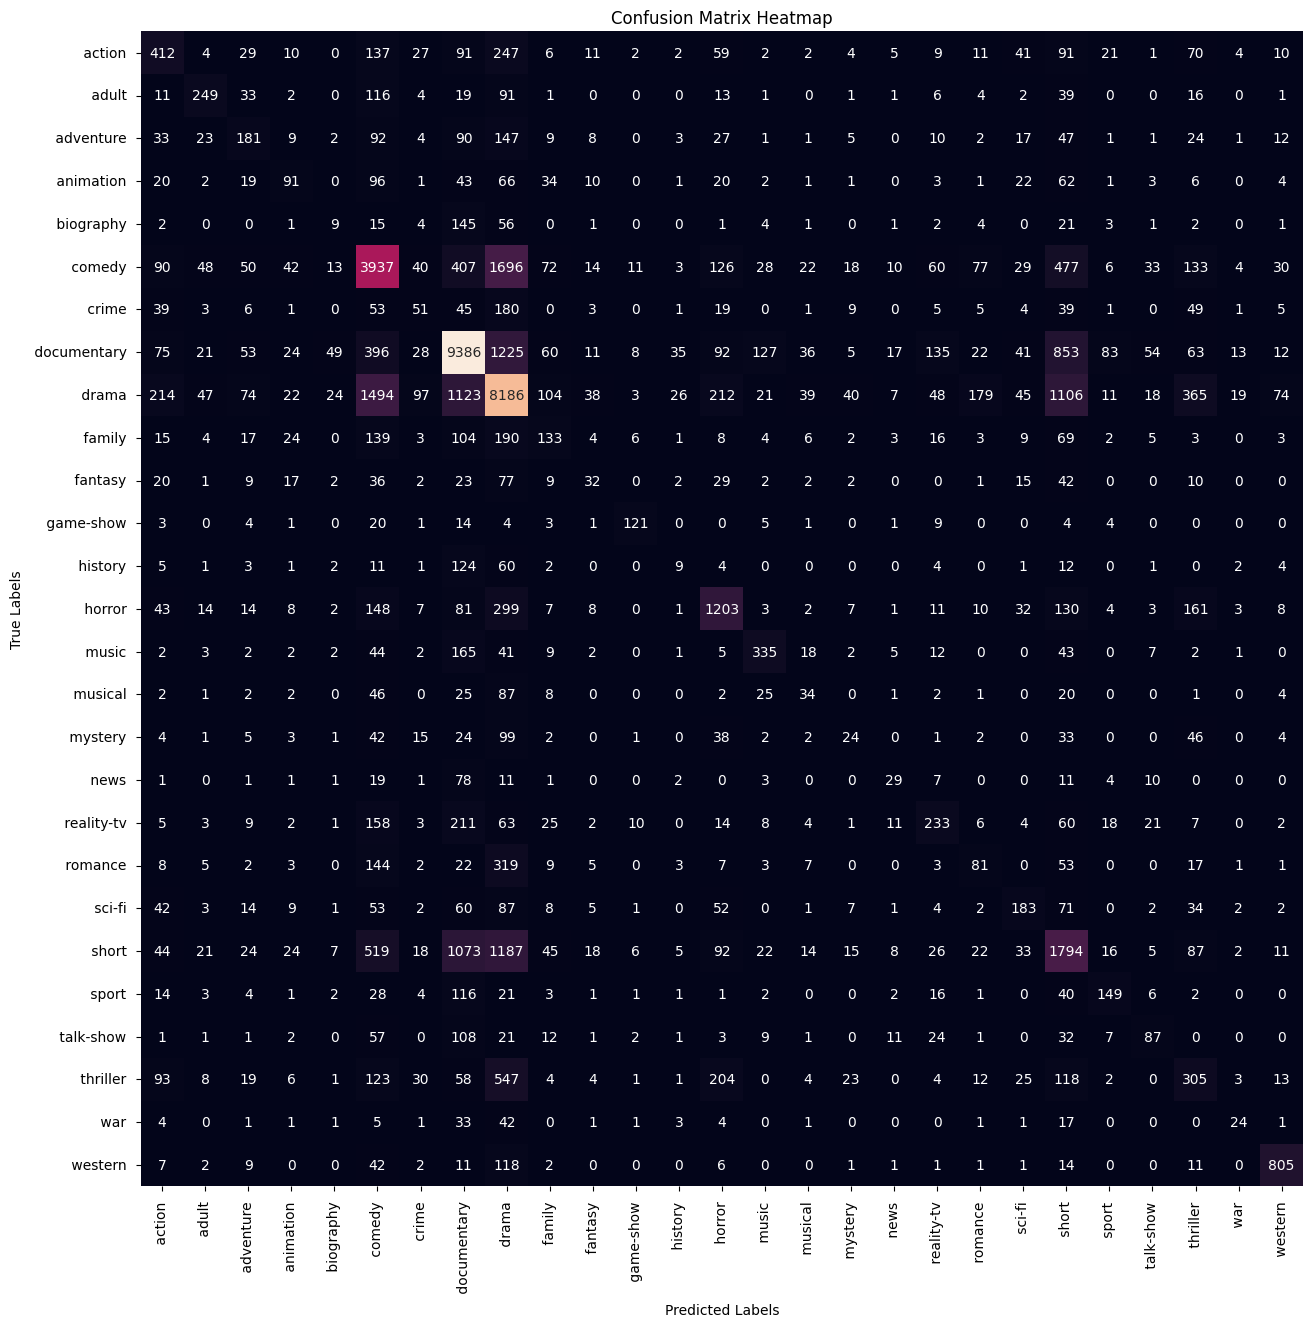

In [ ]:
## Select SVC model

svm = LinearSVC()
svm.fit(x_train1 ,y_train)
print("Model Score on Training data",svm.score(x_train1 ,y_train))
print("Model Score on Training data",svm.score(x_test1 ,y_test))
y_pred = svm.predict(x_test1)
print(classification_report(y_pred ,y_test))
## As we can see from accuracy that the model the not performing well



cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(15, 15))  # Adjust the figure size as needed
sns.heatmap(cm, annot=True, fmt='d', cbar=False,
            xticklabels=class_names, yticklabels=class_names)  # Replace 'class_names' with your class labels
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()

### RandomForestClassifier

Random Forest - Train Score: 0.999631043961112
Random Forest - Test Score: 0.4832770675374029
               precision    recall  f1-score   support

      action        0.01      0.90      0.01        10
       adult        0.03      0.90      0.06        21
   adventure        0.10      0.63      0.18       122
   animation        0.00      0.20      0.00         5
   biography        0.00      0.00      0.00         1
      comedy        0.25      0.57      0.35      3274
       crime        0.00      1.00      0.00         1
 documentary        0.88      0.55      0.68     20763
       drama        0.85      0.41      0.55     28524
      family        0.02      0.79      0.04        19
     fantasy        0.00      0.00      0.00         0
   game-show        0.45      0.87      0.59       101
     history        0.00      0.00      0.00         2
      horror        0.11      0.75      0.19       320
       music        0.12      0.83      0.21       103
     musical        0.01 

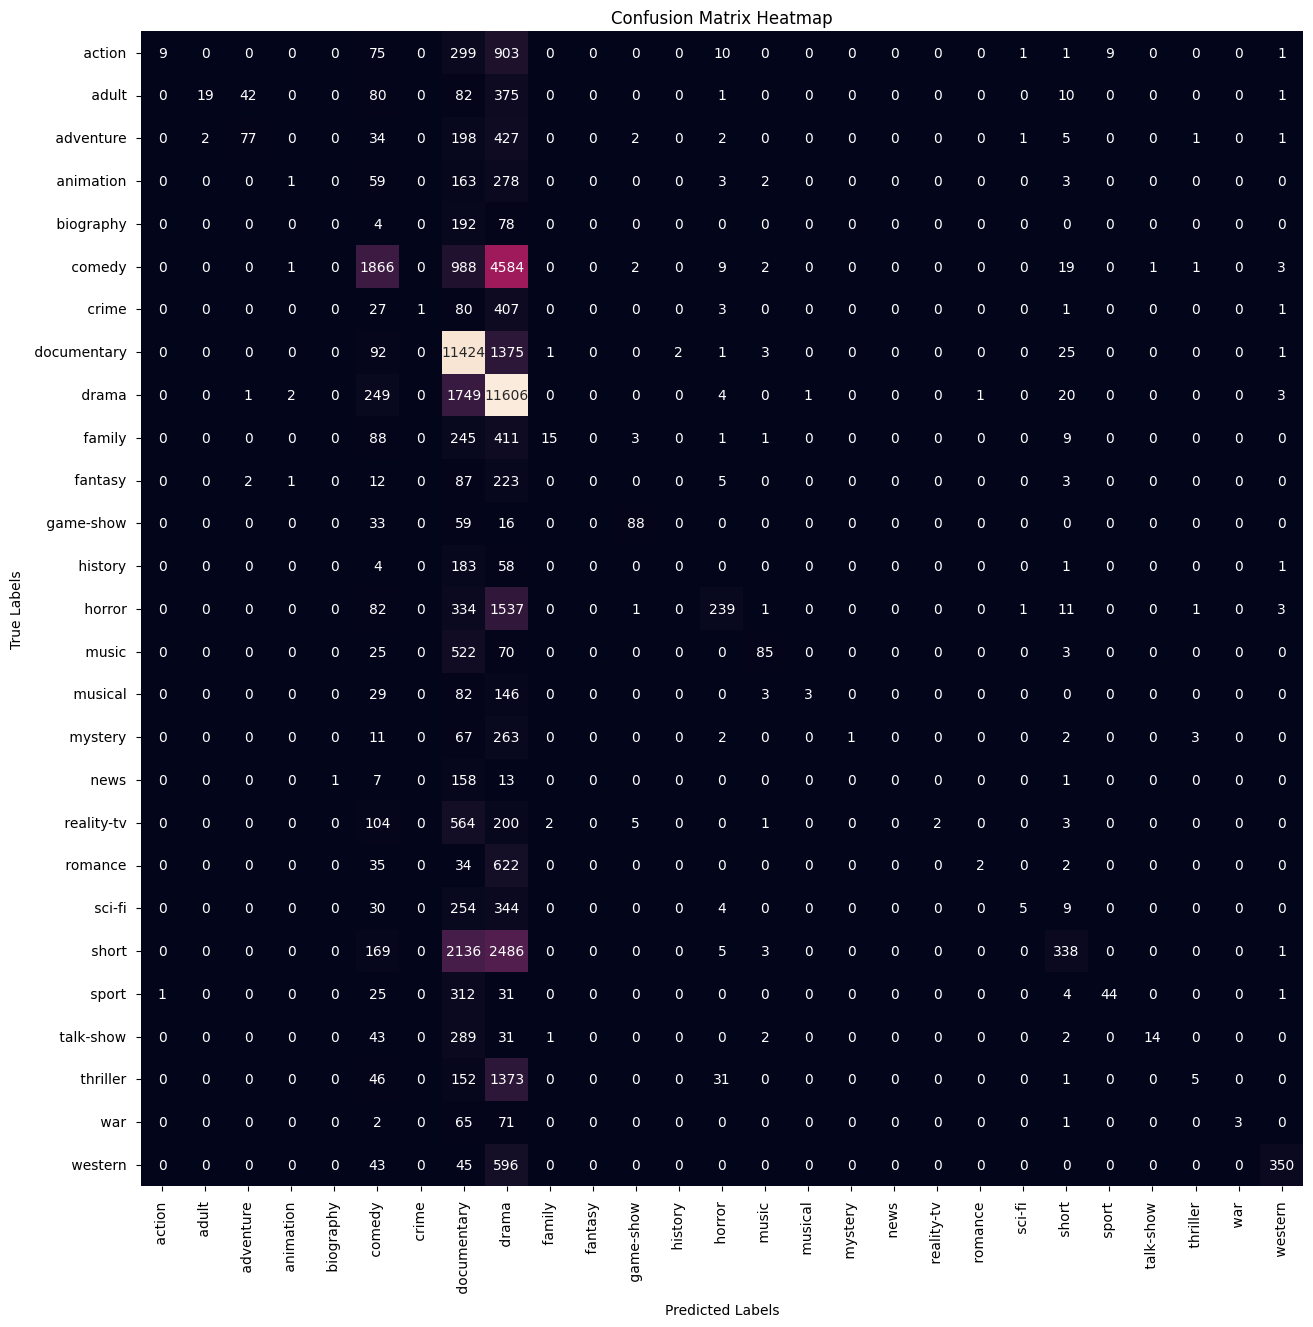

In [ ]:
# Create a Random Forest model
random_forest = RandomForestClassifier()

# Fit the model with GridSearchCV
random_forest.fit(x_train1, y_train)
print("Random Forest - Train Score:",random_forest.score(x_train1, y_train))
print("Random Forest - Test Score:", random_forest.score(x_test1, y_test))

y_pred = random_forest.predict(x_test1)
print(classification_report(y_pred ,y_test))



cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(15, 15))  # Adjust the figure size as needed
sns.heatmap(cm, annot=True, fmt='d', cbar=False,
            xticklabels=class_names, yticklabels=class_names)  # Replace 'class_names' with your class labels
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()

## Now use TfidfVectorizer technique

In [ ]:
## Using TfidfVectorizer technique
vectorizer = TfidfVectorizer()
x_train2 = vectorize.fit_transform(x_train)
x_test2 =  vectorize.transform(x_test)

### MultinomialNB with Tfidf Vectorizer

Model Score on Training data 0.6403232054900658
Model Score on Training data 0.522552437877027
               precision    recall  f1-score   support

      action        0.04      0.69      0.08        80
       adult        0.01      0.78      0.02         9
   adventure        0.06      0.42      0.10       102
   animation        0.00      0.00      0.00         0
   biography        0.00      0.00      0.00         2
      comedy        0.45      0.53      0.49      6372
       crime        0.00      0.00      0.00         1
 documentary        0.90      0.56      0.69     20674
       drama        0.83      0.46      0.59     24510
      family        0.01      0.17      0.01        24
     fantasy        0.00      0.00      0.00        11
   game-show        0.14      0.97      0.25        29
     history        0.00      0.00      0.00         0
      horror        0.27      0.76      0.40       784
       music        0.06      0.79      0.11        52
     musical        0.01

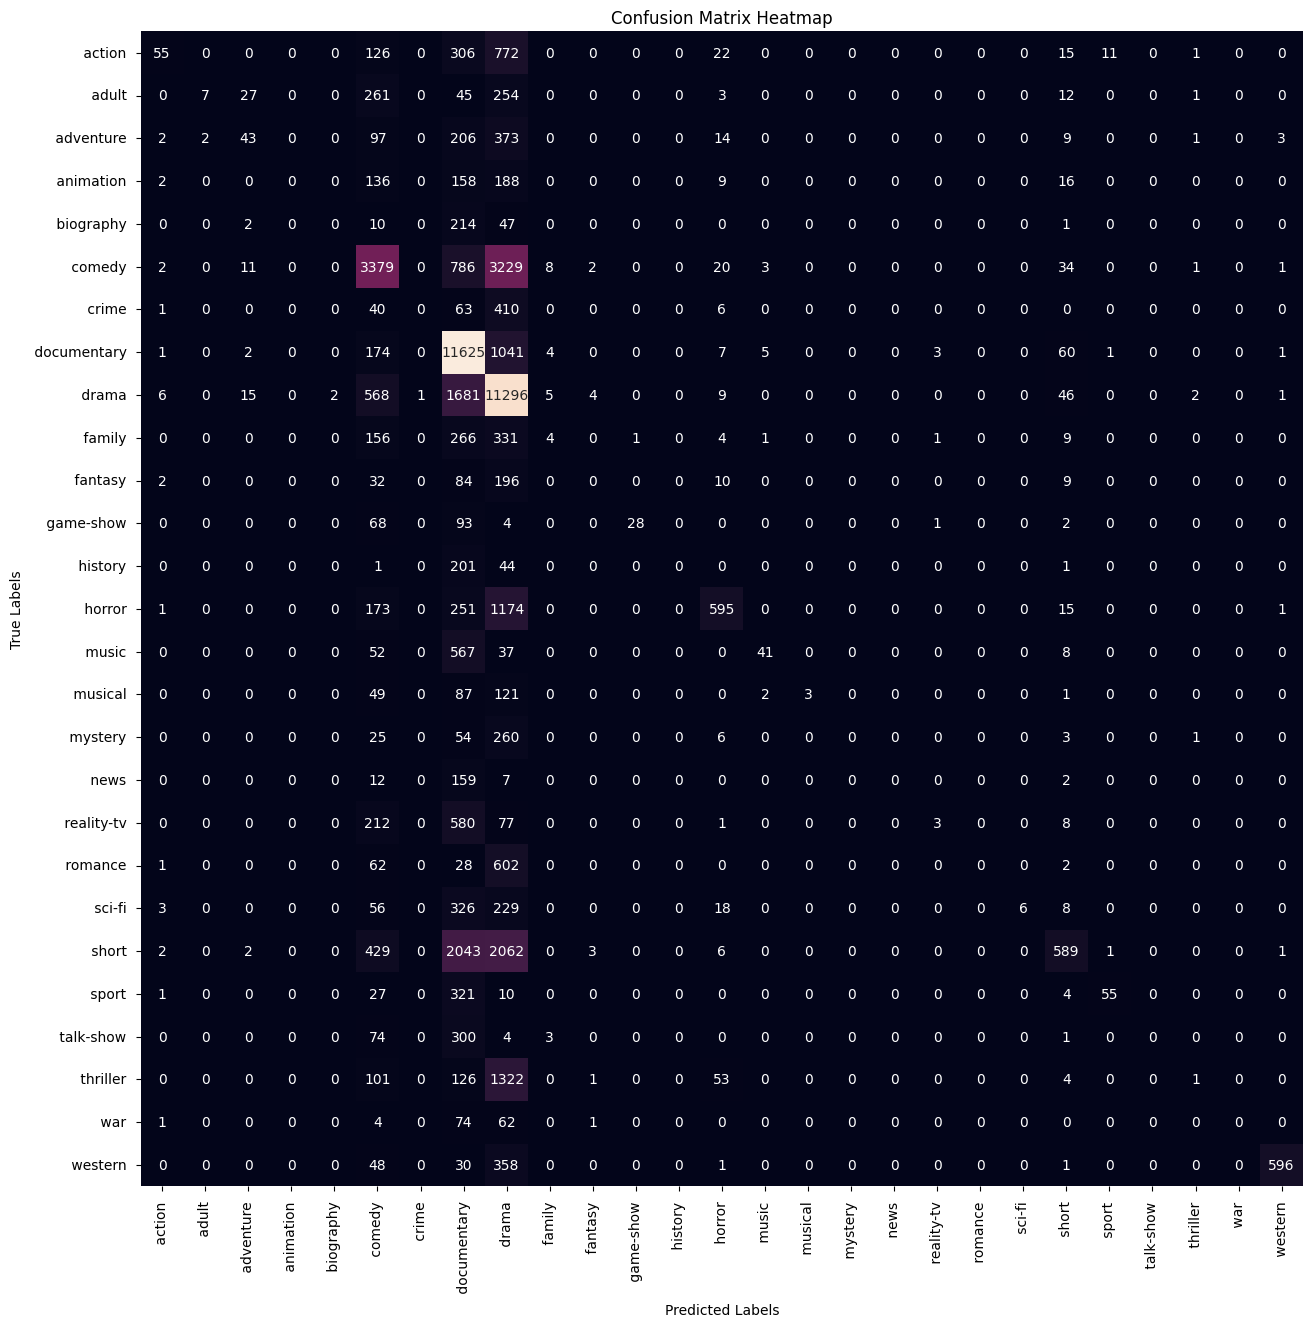

In [ ]:
mnb = MultinomialNB()
mnb.fit(x_train2 ,y_train)
print("Model Score on Training data",mnb.score(x_train2 ,y_train))
print("Model Score on Training data",mnb.score(x_test2 ,y_test))
y_pred = mnb.predict(x_test2)
print(classification_report(y_pred ,y_test))


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(15, 15))  # Adjust the figure size as needed
sns.heatmap(cm, annot=True, fmt='d', cbar=False,
            xticklabels=class_names, yticklabels=class_names)  # Replace 'class_names' with your class labels
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()

### LogisticRegression with TfidfVectorizer

Model Score on Training data 0.997269725312229
Model Score on Training data 0.5667164757319165
               precision    recall  f1-score   support

      action        0.34      0.43      0.38      1053
       adult        0.42      0.66      0.51       389
   adventure        0.23      0.40      0.29       440
   animation        0.17      0.41      0.24       214
   biography        0.00      0.03      0.01        33
      comedy        0.58      0.53      0.56      8167
       crime        0.08      0.22      0.12       197
 documentary        0.78      0.70      0.74     14477
       drama        0.68      0.56      0.62     16529
      family        0.18      0.30      0.23       460
     fantasy        0.09      0.33      0.14        95
   game-show        0.63      0.80      0.70       153
     history        0.04      0.18      0.06        50
      horror        0.58      0.61      0.60      2078
       music        0.50      0.61      0.55       583
     musical        0.10

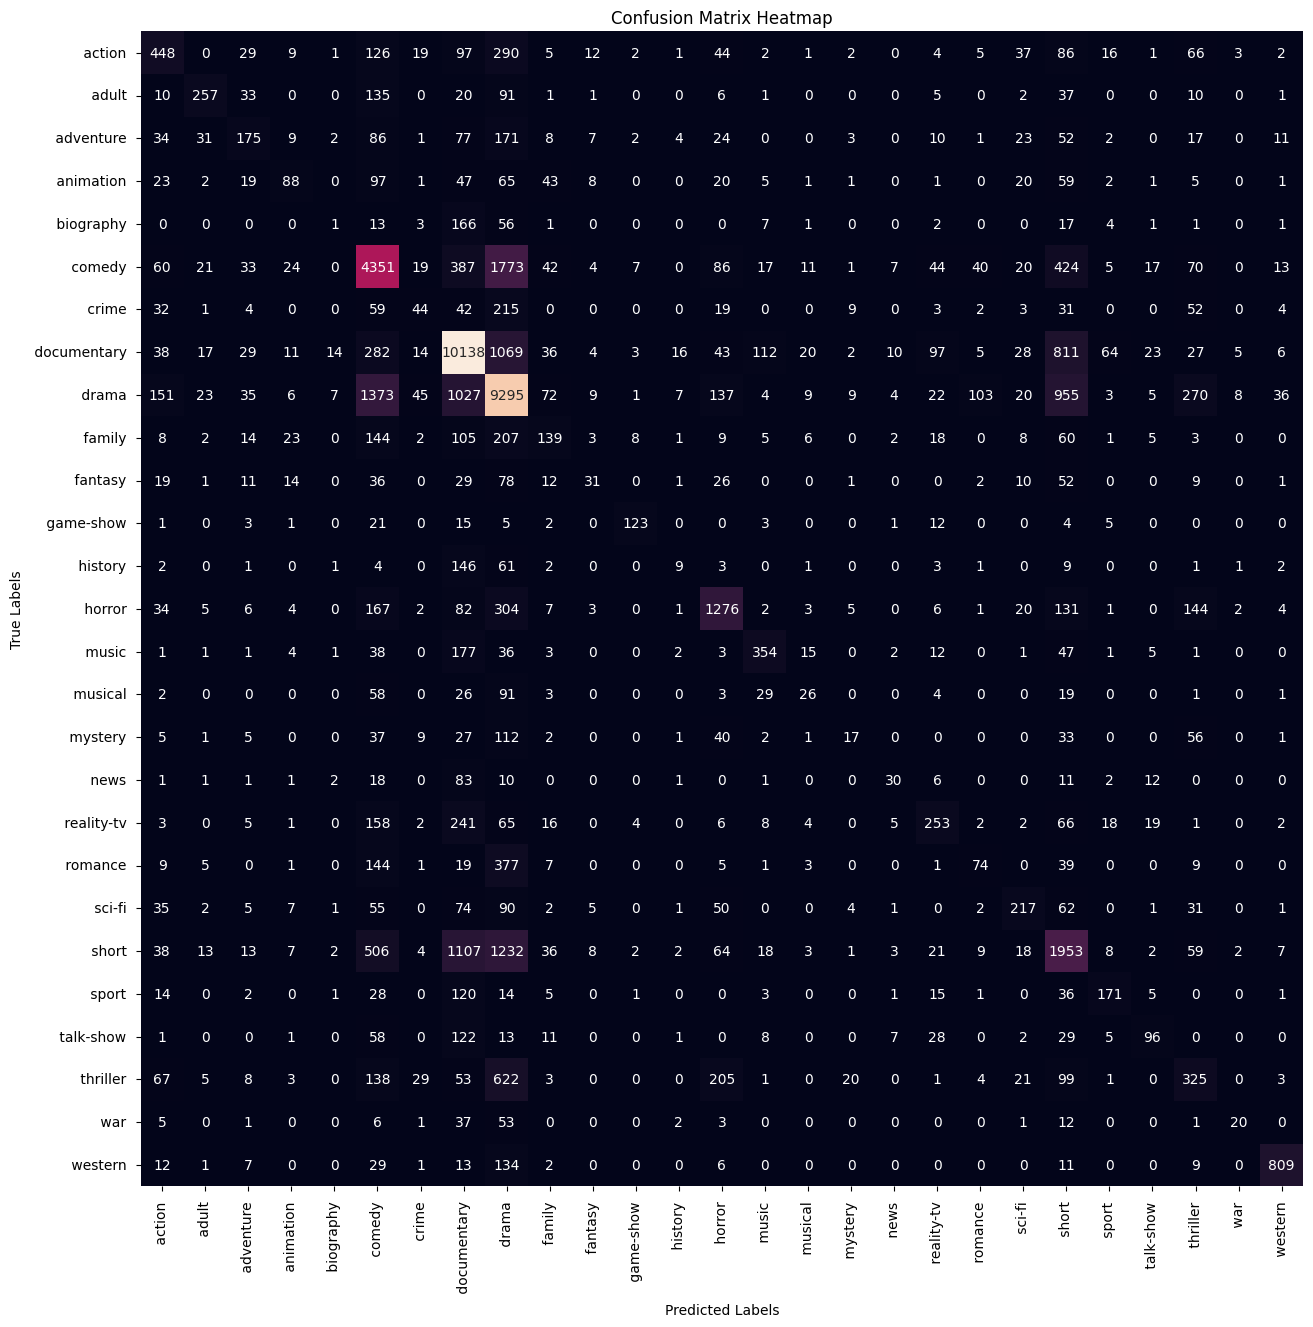

In [ ]:
## select Logistic regression for this
model = LogisticRegression()
model.fit(x_train2 ,y_train)
print("Model Score on Training data",model.score(x_train2 ,y_train))
print("Model Score on Training data",model.score(x_test2 ,y_test))
y_pred = model.predict(x_test2)
print(classification_report(y_pred ,y_test))


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(15, 15))  # Adjust the figure size as needed
sns.heatmap(cm, annot=True, fmt='d', cbar=False,
            xticklabels=class_names, yticklabels=class_names)  # Replace 'class_names' with your class labels
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()

### Support Vector Machine ( SVC ) with TfidfVectorizer

Model Score on Training data 0.9996125961591676
Model Score on Training data 0.5181618610142602
               precision    recall  f1-score   support

      action        0.31      0.34      0.33      1207
       adult        0.41      0.53      0.46       468
   adventure        0.24      0.31      0.27       585
   animation        0.18      0.29      0.22       309
   biography        0.03      0.07      0.05       120
      comedy        0.53      0.49      0.51      7970
       crime        0.10      0.15      0.12       348
 documentary        0.73      0.69      0.71     13680
       drama        0.60      0.54      0.57     15171
      family        0.17      0.23      0.20       568
     fantasy        0.10      0.18      0.12       179
   game-show        0.62      0.70      0.65       174
     history        0.04      0.09      0.05       101
      horror        0.54      0.54      0.54      2241
       music        0.48      0.55      0.51       609
     musical        0.1

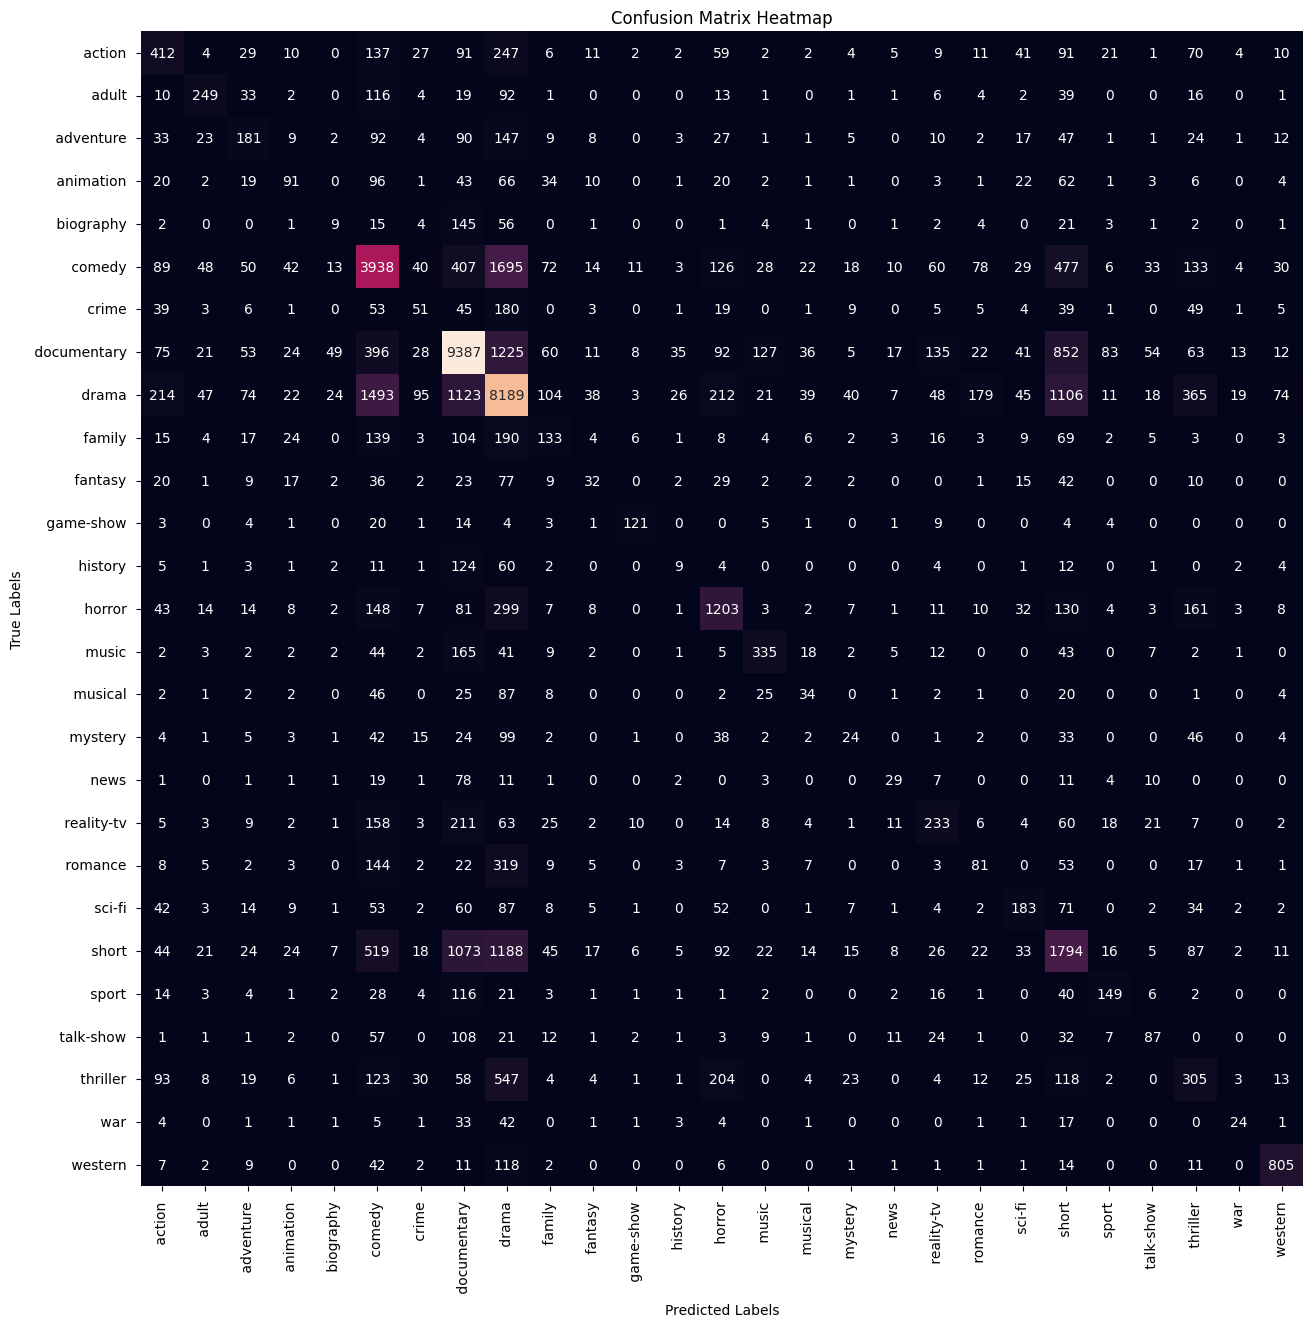

In [ ]:
## Select SVC model

svm = LinearSVC()
svm.fit(x_train2 ,y_train)
print("Model Score on Training data",svm.score(x_train2 ,y_train))
print("Model Score on Training data",svm.score(x_test2 ,y_test))
y_pred = svm.predict(x_test2)
print(classification_report(y_pred ,y_test))
## As we can see from accuracy that the model the not performing well



cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(15, 15))  # Adjust the figure size as needed
sns.heatmap(cm, annot=True, fmt='d', cbar=False,
            xticklabels=class_names, yticklabels=class_names)  # Replace 'class_names' with your class labels
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()

### RandomForestClassifier with TfidfVectorizer

Random Forest - Train Score: 0.999631043961112
Random Forest - Test Score: 0.48311103731990335
               precision    recall  f1-score   support

      action        0.01      0.71      0.02        17
       adult        0.04      0.82      0.08        33
   adventure        0.11      0.62      0.18       127
   animation        0.00      0.20      0.00         5
   biography        0.00      0.00      0.00         1
      comedy        0.25      0.56      0.34      3334
       crime        0.00      1.00      0.00         1
 documentary        0.88      0.55      0.68     20779
       drama        0.85      0.41      0.55     28411
      family        0.02      0.79      0.04        19
     fantasy        0.00      0.00      0.00         1
   game-show        0.41      0.88      0.56        92
     history        0.00      0.00      0.00         2
      horror        0.11      0.72      0.19       346
       music        0.12      0.80      0.20       102
     musical        0.02

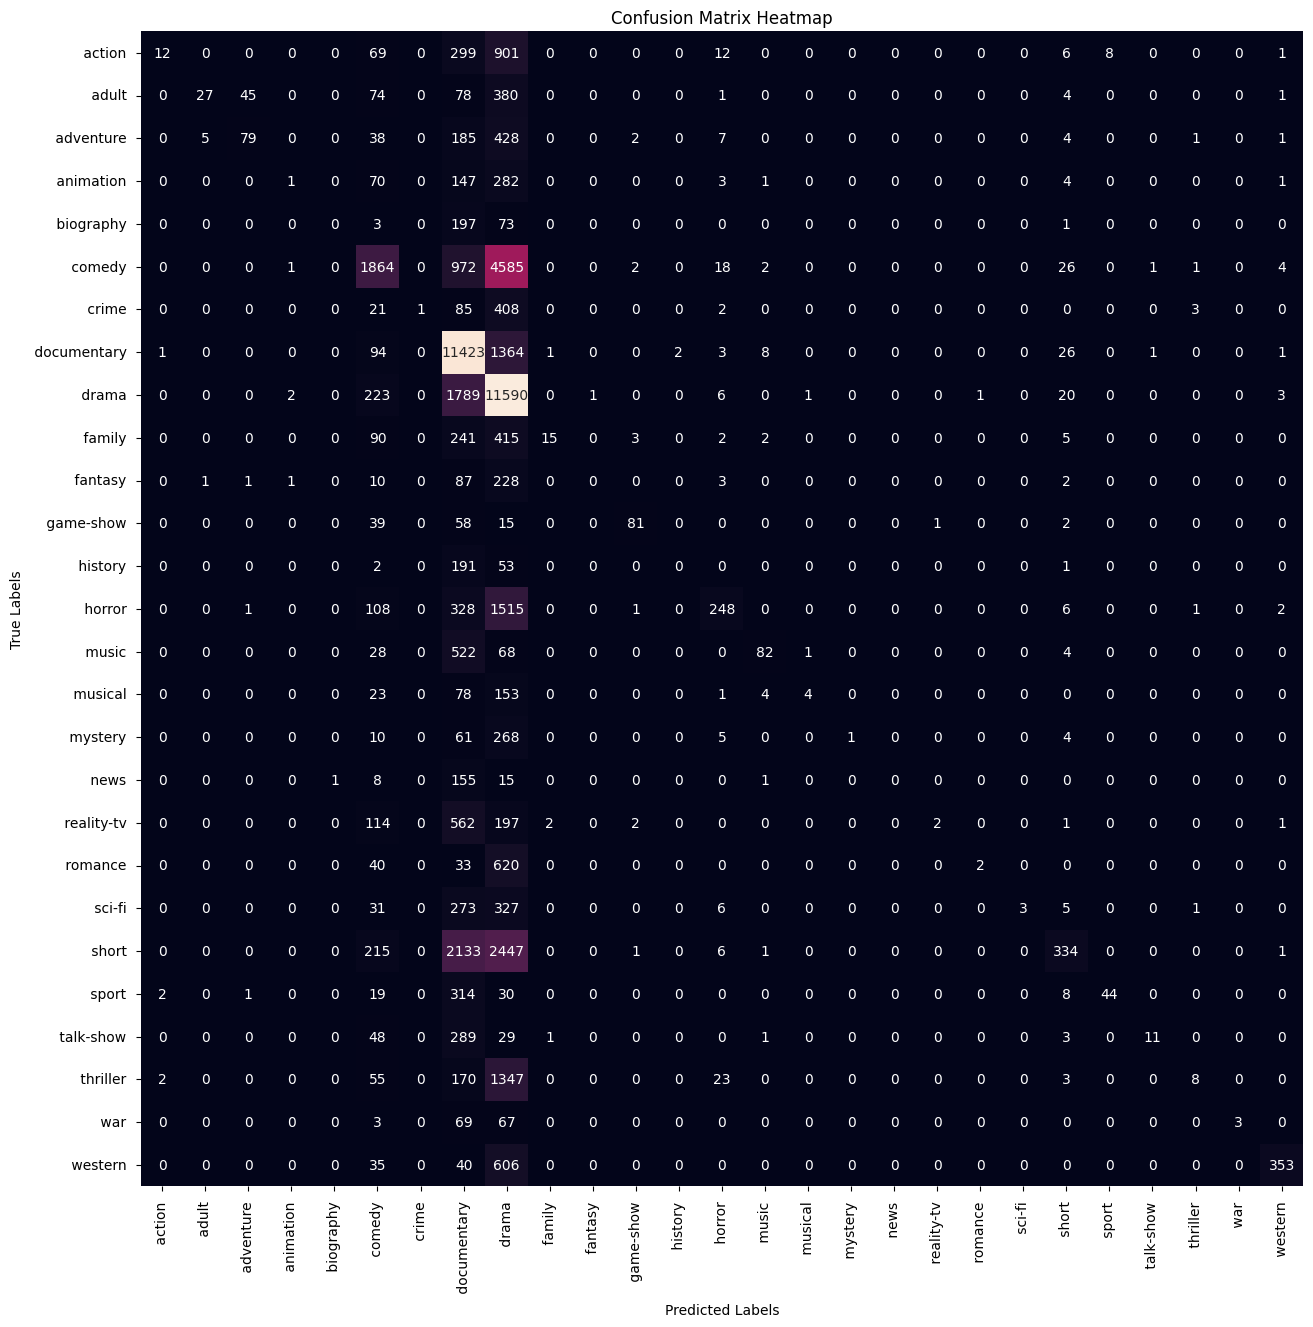

In [ ]:
# Create a Random Forest model
random_forest = RandomForestClassifier()


# Fit the model with GridSearchCV
random_forest.fit(x_train2, y_train)


print("Random Forest - Train Score:",random_forest.score(x_train2, y_train))
print("Random Forest - Test Score:", random_forest.score(x_test2, y_test))

y_pred = random_forest.predict(x_test2)
print(classification_report(y_pred ,y_test))



cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(15, 15))  # Adjust the figure size as needed
sns.heatmap(cm, annot=True, fmt='d', cbar=False,
            xticklabels=class_names, yticklabels=class_names)  # Replace 'class_names' with your class labels
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()